In [60]:
suppressMessages(library(ArchR))
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
suppressMessages(library(dplyr))
suppressMessages(library(tidyr))
suppressMessages(library(cowplot))
suppressMessages(library(future))

In [61]:
out_dir <- "../../results/04_single_cell_access_atac/14_create_seurat"

if(!dir.exists(out_dir)){
    dir.create(out_dir, recursive = TRUE)
}

In [62]:
proj <- loadArchRProject("../../results/04_single_cell_access_atac/13_create_archr_project", 
showLogo = FALSE)
df <- as.data.frame(proj@cellColData)

Successfully loaded ArchRProject!



In [63]:
mean(df$nFrags)

[1] 11228.17

In [64]:
atac.counts <- readRDS("../../results/04_single_cell_access_atac/13_create_archr_project/PeakMatrix.Rds")

In [65]:
dim(atac.counts)

[1] 139613   2024

In [66]:
# create ATAC assay and add it to the object
chrom_assay <- CreateChromatinAssay(
  counts = atac.counts,
  sep = c("_", "_"),
  min.features = 1, 
  min.cells = 10
)

obj.atac <- CreateSeuratObject(
  counts = chrom_assay,
  assay = "ATAC",
  meta.data = df
)

In [67]:
obj.atac@meta.data$nFrags_log10 <- log10(obj.atac@meta.data$nFrags)

In [68]:
obj.atac

An object of class Seurat 
138953 features across 2024 samples within 1 assay 
Active assay: ATAC (138953 features, 0 variable features)
 2 layers present: counts, data

In [69]:
obj.atac <- FindTopFeatures(obj.atac, min.cutoff = "q1")
obj.atac <- RunTFIDF(obj.atac, method = 1)
obj.atac <- RunSVD(obj.atac, n = 30, scale.embeddings = FALSE)

Performing TF-IDF normalization

Running SVD



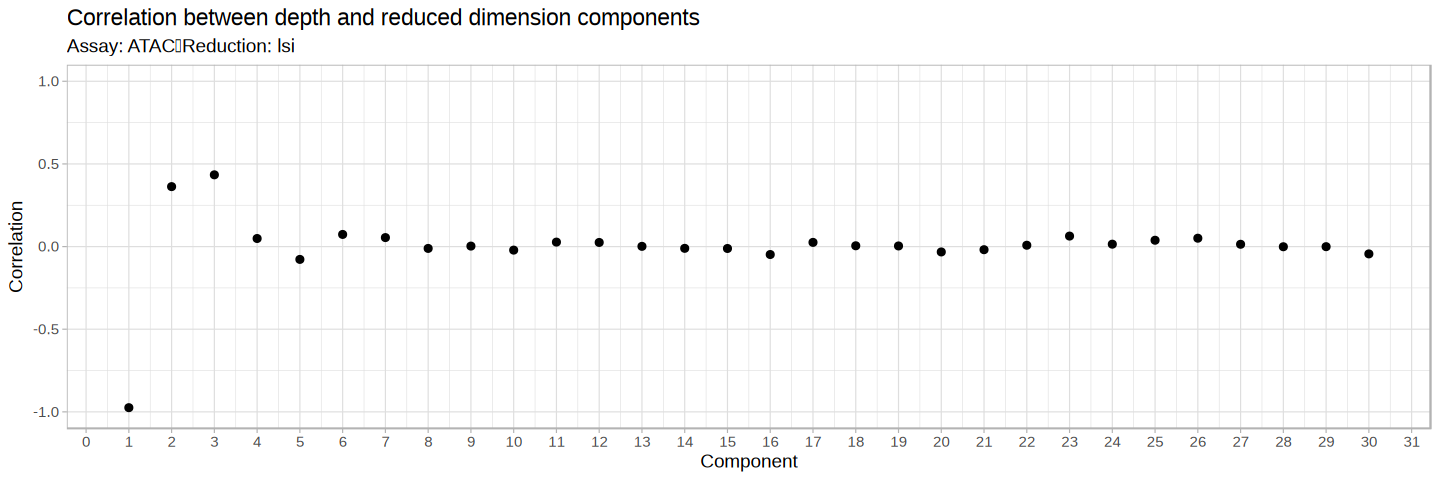

In [70]:
options(repr.plot.height = 4, repr.plot.width = 12)
DepthCor(obj.atac, reduction = 'lsi', n = 30)

In [71]:
obj.atac <- RunUMAP(object = obj.atac, 
               reduction = 'lsi',
               reduction.name = "umap_atac",
               dims = 2:15, 
               metric = "euclidean",
               verbose = FALSE)

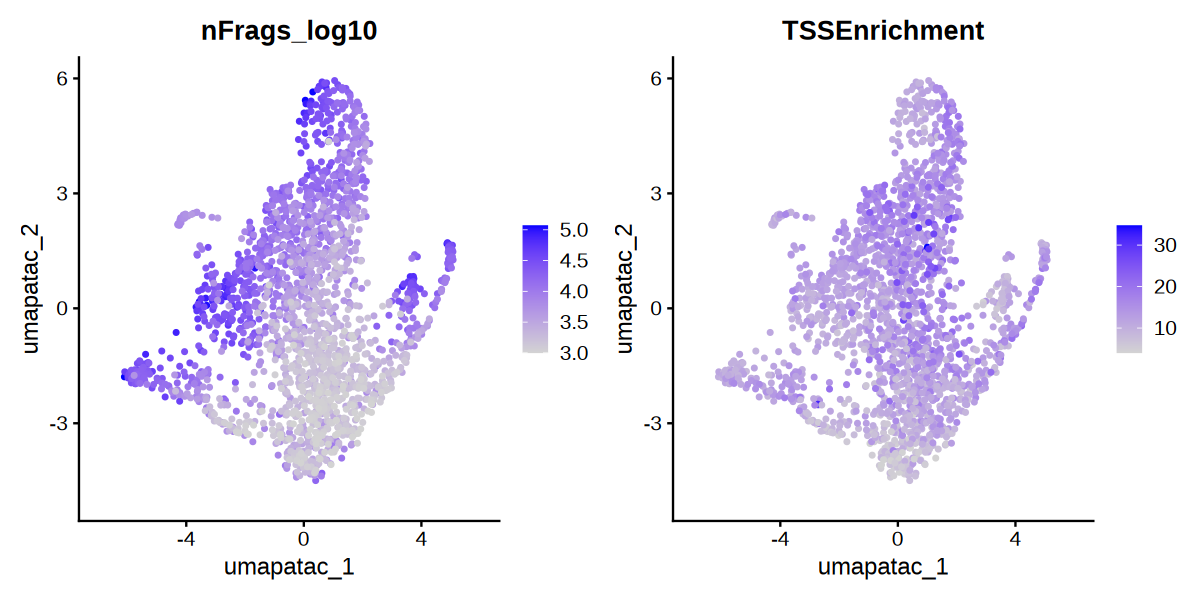

In [72]:
options(repr.plot.height = 5, repr.plot.width = 10)

FeaturePlot(obj.atac, reduction = "umap_atac", features = c("nFrags_log10", "TSSEnrichment"))

In [73]:
DefaultAssay(obj.atac) <- "ATAC"

obj.atac <- FindNeighbors(object = obj.atac, reduction = 'lsi', dims = 2:15)
obj.atac <- FindClusters(object = obj.atac, verbose = FALSE, resolution = 1.0)

Computing nearest neighbor graph



Computing SNN



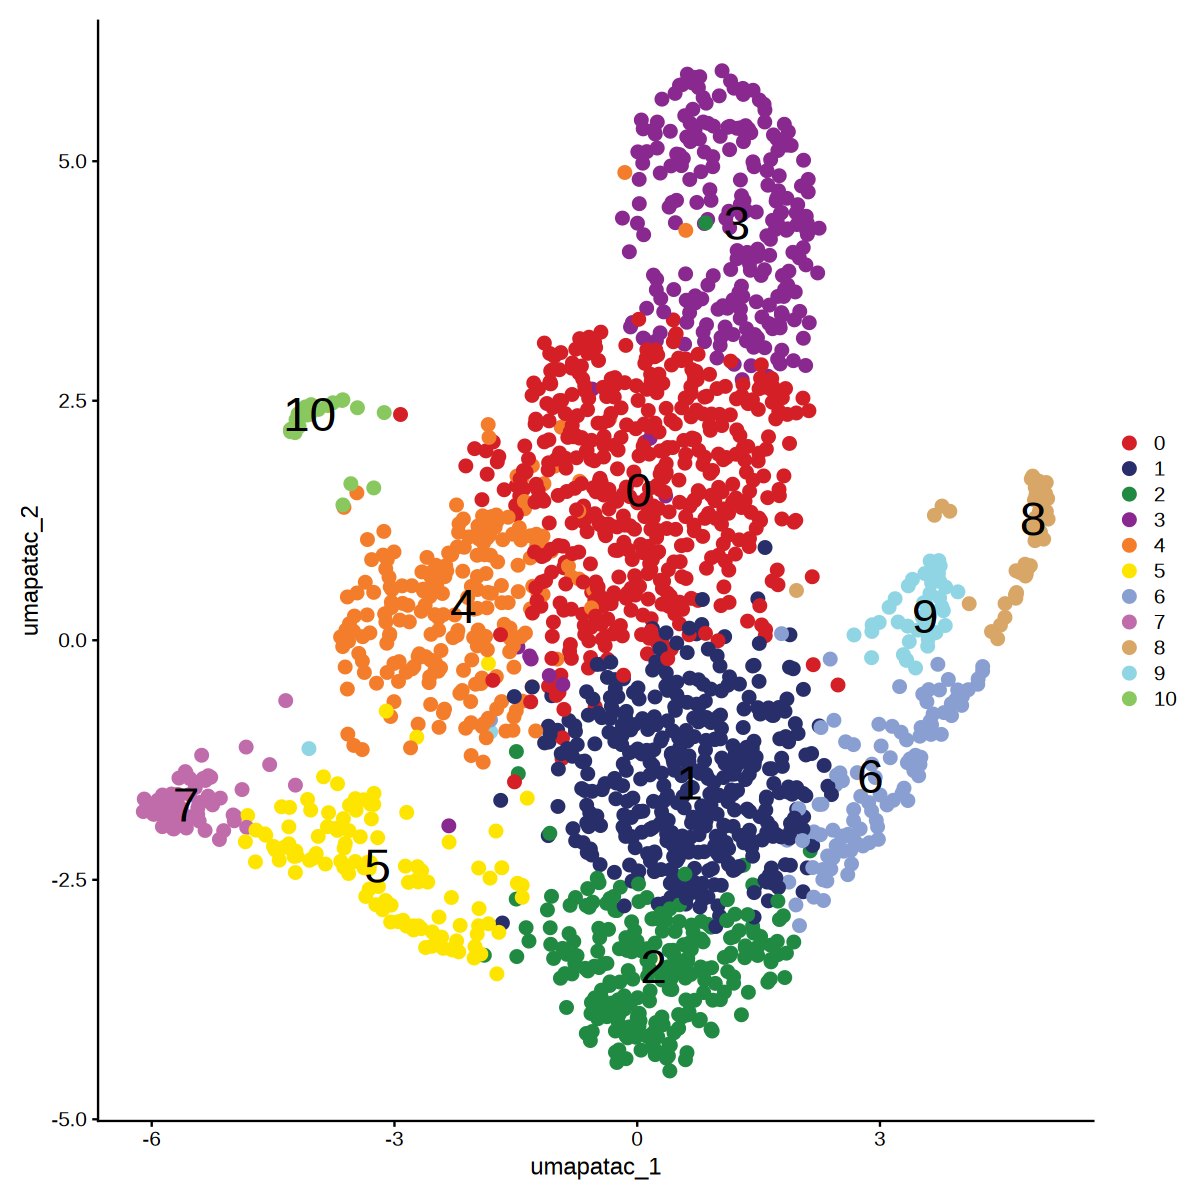

In [74]:
options(repr.plot.height = 10, repr.plot.width = 10)

p <- DimPlot(object = obj.atac, label = TRUE, label.size = 10, pt.size = 3, 
cols = ArchR::paletteDiscrete(obj.atac$seurat_clusters))

print(p)

ggsave(glue::glue("{out_dir}/umap_atac_clusters.pdf"), plot = p, width = 10, height = 10)

In [75]:
obj.rna <- readRDS("../../results/09_scRNA_mouseAirwayCell/03_find_markers/mouse_airway_seurat_obj.rds")

In [76]:
cols <- c("Basal" = "#0875b3", 
          "Club" = "#057d34",
          "Ciliated" = "#c10020",
          "Goblet" = "#ffb300",
          "PNEC" = "#f78a3a",
          "Ionocyte" = "#803e75",
          "Tuft" = "#a6bdd7")

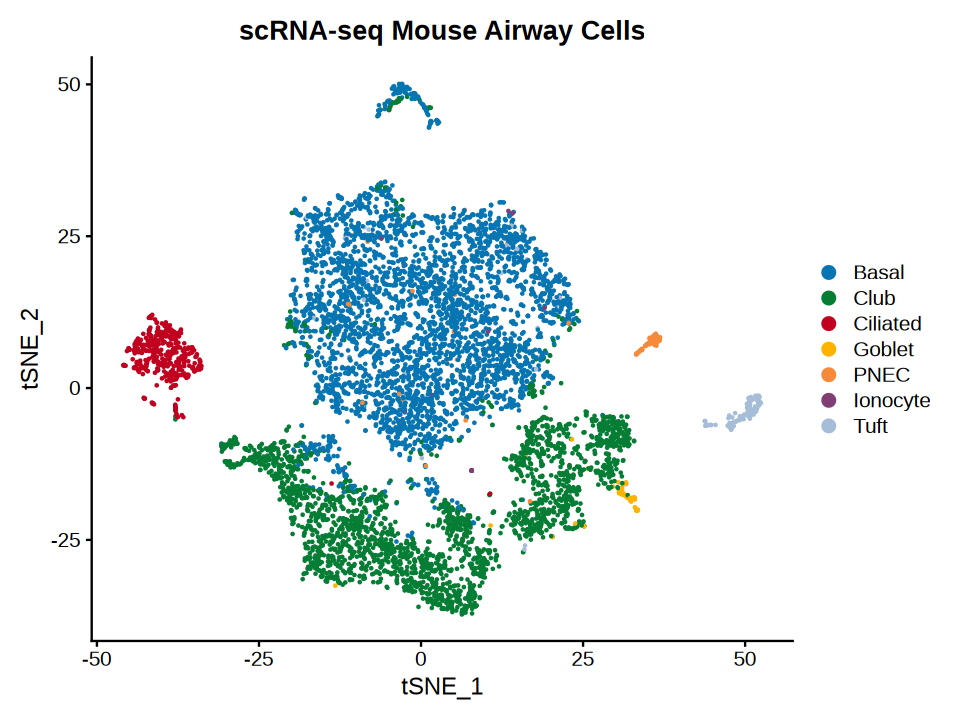

In [77]:
options(repr.plot.height = 6, repr.plot.width = 8)

DimPlot(obj.rna, reduction = "tsne", group.by = "cell_type", pt.size = 0.1, cols = cols) + 
    ggtitle("scRNA-seq Mouse Airway Cells")

In [78]:
gene.activities <- readRDS("../../results/04_single_cell_access_atac/13_create_archr_project/GeneScoreMatrix.Rds")

dim(gene.activities)

[1] 32899  2024

In [79]:
gene.use <- intersect(rownames(gene.activities),
                     rownames(obj.rna))

In [80]:
length(gene.use)

[1] 16887

In [81]:
obj.atac[['GeneActivity']] <- CreateAssayObject(counts = gene.activities[gene.use, colnames(obj.atac)])

DefaultAssay(obj.atac) <- "GeneActivity"

obj.atac <- obj.atac %>% 
        NormalizeData() %>%
        FindVariableFeatures() %>%
        ScaleData()

Centering and scaling data matrix



In [82]:
# Find markers using gene activity scores
all.markers <- FindAllMarkers(obj.atac, 
                              only.pos = TRUE, 
                              min.pct = 0.25, 
                              logfc.threshold = 0.25)

Calculating cluster 0



Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9

Calculating cluster 10



In [83]:
head(all.markers)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
Bpifa1,5.269964e-19,1.0069862,0.483,0.302,8.899389e-15,0,Bpifa1
Alas1,2.155437e-18,0.4519450,0.715,0.507,3.639886e-14,0,Alas1
Fmo3,1.752235e-16,0.5498901,0.677,0.487,2.959000e-12,0,Fmo3
Cyp4b1,8.342659e-16,0.5274087,0.621,0.454,1.408825e-11,0,Cyp4b1
Gm29168,1.096191e-14,0.4206405,0.840,0.654,1.851138e-10,0,Gm29168
Ccdc6,1.584064e-14,0.2900923,0.776,0.581,2.675009e-10,0,Ccdc6


In [84]:
# write markers to excel file and split by cluster
library(openxlsx)

split_col <- "cluster"
sheets <- split(all.markers, all.markers[[split_col]])

wb <- createWorkbook()

for (nm in names(sheets)) {
  addWorksheet(wb, nm)
  writeDataTable(wb, nm, sheets[[nm]])
}

saveWorkbook(wb, glue::glue("{out_dir}/atac_clusters_gene_activity_markers.xlsx"), overwrite = TRUE)

# write.csv(all.markers, 
#           file = glue::glue("{out_dir}/atac_clusters_gene_activity_markers.csv"),
#           row.names = FALSE)

In [85]:
head(obj.atac@meta.data)

,orig.ident,nCount_ATAC,nFeature_ATAC,Sample,TSSEnrichment,ReadsInTSS,ReadsInPromoter,PromoterRatio,PassQC,NucleosomeRatio,⋯,nDiFrags,DoubletScore,DoubletEnrichment,ReadsInPeaks,FRIP,nFrags_log10,ATAC_snn_res.1,seurat_clusters,nCount_GeneActivity,nFeature_GeneActivity
,<fct>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<int>
mouse#GAGGCTCCAGAGTCGA,SeuratProject,33439,33439,mouse,10.229,10326,33420,0.1420073,1,4.658300,⋯,61008,227.8374,8.5,71761,0.3051712,5.070666,7,7,6403.629,15631
mouse#CTGTATTTCGTATAGC,SeuratProject,35815,35815,mouse,9.869,10102,33263,0.1442505,1,3.783669,⋯,57162,323.3062,14.2,76906,0.3337036,5.061814,3,3,6598.396,15718
mouse#TATCGAGGTAACGTAA,SeuratProject,35117,35117,mouse,10.541,10338,33123,0.1436471,1,3.778984,⋯,56647,323.3062,12.7,75636,0.3285122,5.061803,3,3,6524.608,15597
mouse#CGCAGGTAGAACGTCG,SeuratProject,30979,30979,mouse,9.835,8950,29135,0.1355709,1,4.227330,⋯,55373,323.3062,12.1,63549,0.2960366,5.031219,4,4,6413.499,15501
mouse#TTCTGTAGTATCCTTT,SeuratProject,30426,30426,mouse,8.935,8194,27820,0.1300267,1,3.927591,⋯,53227,153.5944,6.8,63975,0.2993655,5.029294,4,4,6445.644,15409
mouse#GCTTGCTGTTGTGAGG,SeuratProject,32349,32349,mouse,11.220,9678,30277,0.1502014,1,4.268308,⋯,51956,323.3062,11.5,67739,0.3364074,5.003409,4,4,6552.102,15375


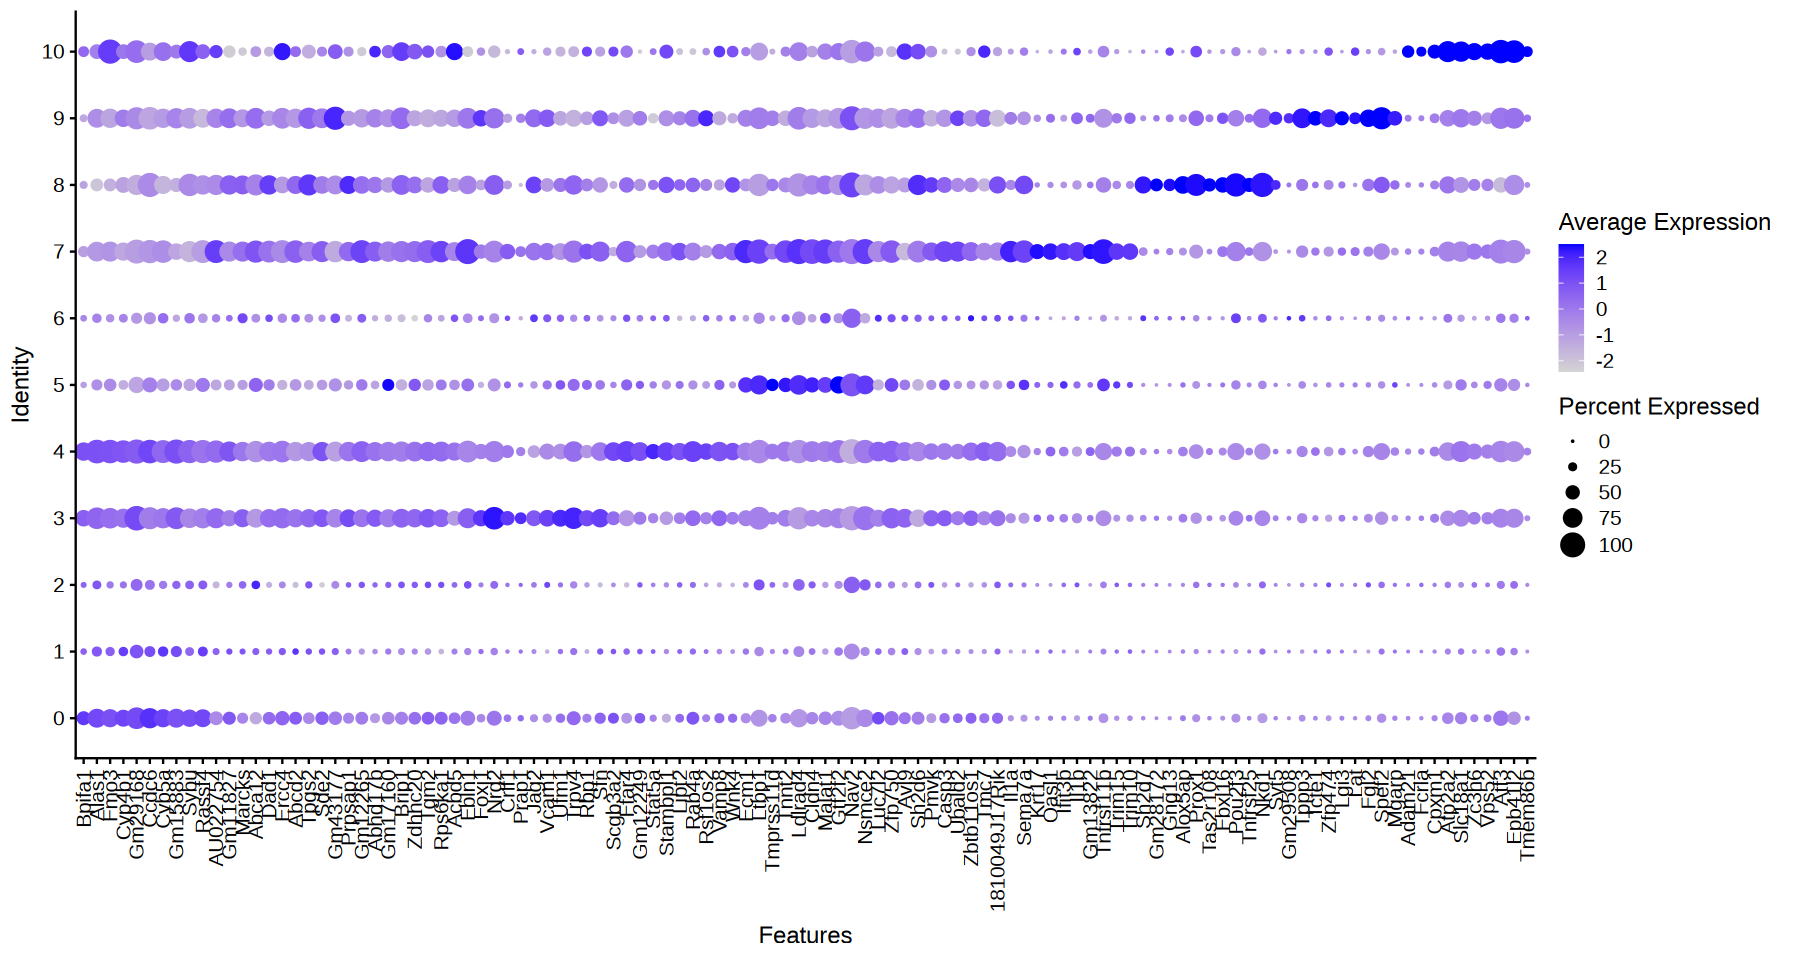

In [86]:
all.markers %>%
    group_by(cluster) %>%
    slice_head(n = 10) %>%
    ungroup() -> top10

options(repr.plot.height = 8, repr.plot.width = 15)

DotPlot(obj.atac, features = top10$gene, group.by = "seurat_clusters") + 
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

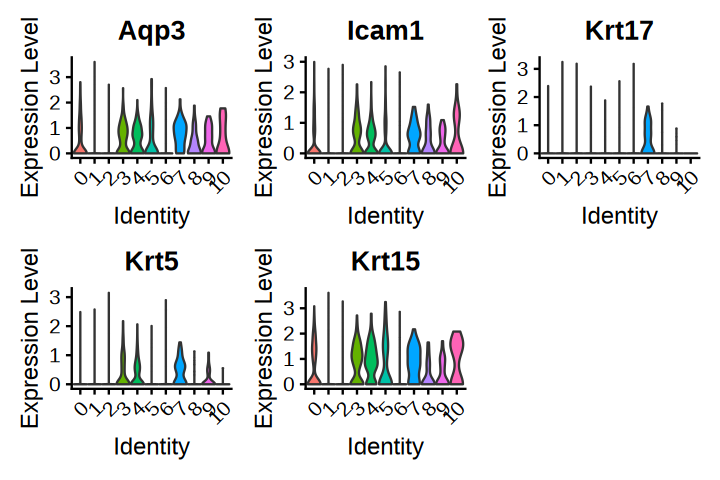

In [87]:
# plot known consensus markers
options(repr.plot.height = 4, repr.plot.width = 6)

VlnPlot(obj.atac, features = c("Aqp3", "Icam1", "Krt17", "Krt5", "Krt15"), 
pt.size = 0, group.by = "seurat_clusters")

In [88]:
transfer.anchors <- FindTransferAnchors(reference = obj.rna,
                                        query = obj.atac,
                                        features = gene.use,
                                        reference.assay = "RNA",
                                        query.assay = "GeneActivity",
                                        reduction = "cca")

Warning message:
“Different features in new layer data than already exists for scale.data”
Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 9208 anchors



In [89]:
# note that we restrict the imputation to variable genes from scRNA-seq, but could impute the
# full transcriptome if we wanted to
refdata <- GetAssayData(obj.rna, assay = "RNA", slot = "data")[gene.use, ]

# refdata (input) contains a scRNA-seq expression matrix for the scRNA-seq cells. imputation
# (output) will contain an imputed scRNA-seq matrix for each of the ATAC cells
imputation <- TransferData(anchorset = transfer.anchors, 
                           refdata = refdata, 
                           weight.reduction = obj.atac[["lsi"]],
                           dims = 2:15)
obj.atac[["RNA"]] <- imputation

Finding integration vectors

Finding integration vector weights

Transfering 16887 features onto reference data

Warning message:
“Layer counts isn't present in the assay object; returning NULL”


In [90]:
obj.atac

An object of class Seurat 
172727 features across 2024 samples within 3 assays 
Active assay: GeneActivity (16887 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 other assays present: ATAC, RNA
 2 dimensional reductions calculated: lsi, umap_atac

In [91]:
saveRDS(obj.atac, file = glue::glue("{out_dir}/seurat_atac_obj_with_clusters.Rds"))

In [92]:
DefaultAssay(obj.atac) <- "RNA"
obj.rna$tech <- "RNA"
obj.atac$tech <- "ATAC"
coembed <- merge(x = obj.atac, y = obj.rna)

In [93]:
#Finally, we run PCA and UMAP on this combined object, to visualize the co-embedding of both datasets
coembed <- coembed %>%
    ScaleData(features = gene.use, do.scale = FALSE) %>%
    FindVariableFeatures() %>%
    RunPCA(verbose = FALSE) %>%
    RunUMAP(dims = 1:30, verbose = FALSE)

Centering data matrix

Finding variable features for layer counts.2

Warning message in PrepDR5(object = object, features = features, layer = layer, :
“The following features were not available: Lrmp, BC048546, Gm933, 1700007K13Rik, Tctex1d4, 1700001C02Rik, Ccdc67, 2810417H13Rik, 1700026L06Rik, Fam92b, Nov, Selm, Gm9573, 1700007G11Rik, 1700001L19Rik, 1810046K07Rik, 8430408G22Rik, Fam64a, Gm166, Lrrc48, Ccpg1os, Hist1h1c, 1500015O10Rik, 4932443I19Rik, 1700003M02Rik, 1190002F15Rik, H2afx, 1700101E01Rik, Tmem246, H1fx, 4833427G06Rik, 1700028P14Rik, 6430531B16Rik, Cyr61, 1700026D08Rik, 1700019L03Rik, A230065H16Rik, Gm7173, 4732456N10Rik, RP24-191C15.5, BC030870, Pcdhga8-ENSMUSG00000023036, Hist1h4j, 1700040L02Rik, 2010015M23Rik, mt-Nd1, Dnaic2, RP23-477O13.1, Ccdc108, 1700013F07Rik, Ccdc37, Murc, 4930518I15Rik, 2210011C24Rik, Tctex1d2, 1700086L19Rik, 5430421N21Rik, Ccdc155, Deb1, RP24-183E22.2, 1110004E09Rik, Gm43194, Dnaic1, Gm21992, Dyx1c1, BC089491, 2300005B03Rik, G6b, Mettl20, Fam57a, 

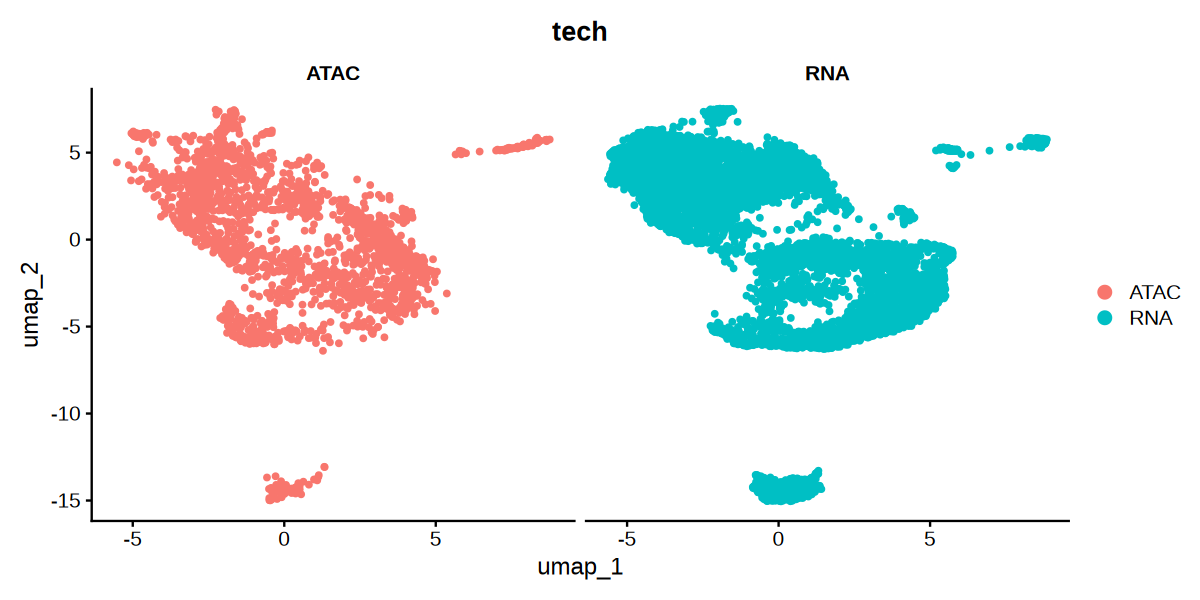

In [94]:
options(repr.plot.height = 5, repr.plot.width = 10)

DimPlot(coembed, group.by = "tech", split.by = "tech", reduction = "umap", pt.size = 1)

In [95]:
celltype.predictions <- TransferData(anchorset = transfer.anchors, 
refdata = obj.rna$cell_type,
weight.reduction = obj.atac[["lsi"]],
                           dims = 2:15)

Finding integration vectors

Finding integration vector weights



Predicting cell labels



In [96]:
obj.atac <- AddMetaData(obj.atac, metadata = celltype.predictions)

In [97]:
head(obj.atac@meta.data)

,orig.ident,nCount_ATAC,nFeature_ATAC,Sample,TSSEnrichment,ReadsInTSS,ReadsInPromoter,PromoterRatio,PassQC,NucleosomeRatio,⋯,tech,predicted.id,prediction.score.Club,prediction.score.Basal,prediction.score.Ciliated,prediction.score.Tuft,prediction.score.PNEC,prediction.score.Goblet,prediction.score.Ionocyte,prediction.score.max
,<fct>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
mouse#GAGGCTCCAGAGTCGA,SeuratProject,33439,33439,mouse,10.229,10326,33420,0.1420073,1,4.658300,⋯,ATAC,Basal,0.1154450,0.8724806,0.000000000,0.01207436,0,0,0,0.8724806
mouse#CTGTATTTCGTATAGC,SeuratProject,35815,35815,mouse,9.869,10102,33263,0.1442505,1,3.783669,⋯,ATAC,Basal,0.1585092,0.8219752,0.019515598,0.00000000,0,0,0,0.8219752
mouse#TATCGAGGTAACGTAA,SeuratProject,35117,35117,mouse,10.541,10338,33123,0.1436471,1,3.778984,⋯,ATAC,Basal,0.1565965,0.8434035,0.000000000,0.00000000,0,0,0,0.8434035
mouse#CGCAGGTAGAACGTCG,SeuratProject,30979,30979,mouse,9.835,8950,29135,0.1355709,1,4.227330,⋯,ATAC,Basal,0.1539225,0.8405437,0.005533754,0.00000000,0,0,0,0.8405437
mouse#TTCTGTAGTATCCTTT,SeuratProject,30426,30426,mouse,8.935,8194,27820,0.1300267,1,3.927591,⋯,ATAC,Club,0.5089049,0.4910951,0.000000000,0.00000000,0,0,0,0.5089049
mouse#GCTTGCTGTTGTGAGG,SeuratProject,32349,32349,mouse,11.220,9678,30277,0.1502014,1,4.268308,⋯,ATAC,Basal,0.0923843,0.9076157,0.000000000,0.00000000,0,0,0,0.9076157


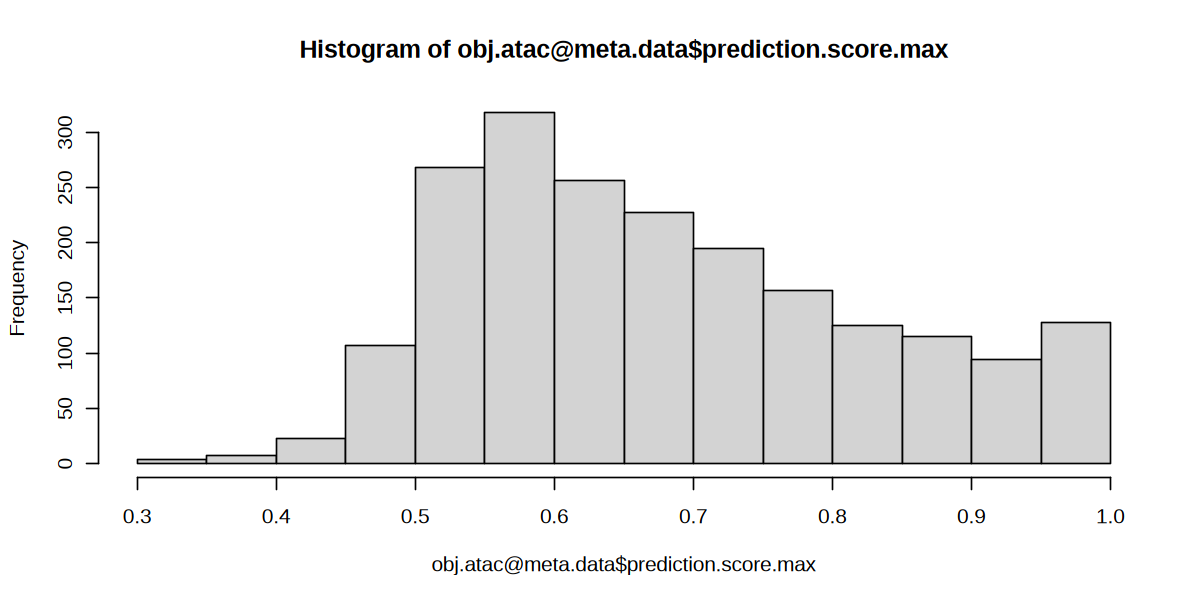

In [98]:
hist(obj.atac@meta.data$prediction.score.max)

In [99]:
# only keep prediction.score.max > 0.8
obj.atac <- subset(obj.atac, subset = prediction.score.max > 0.5)

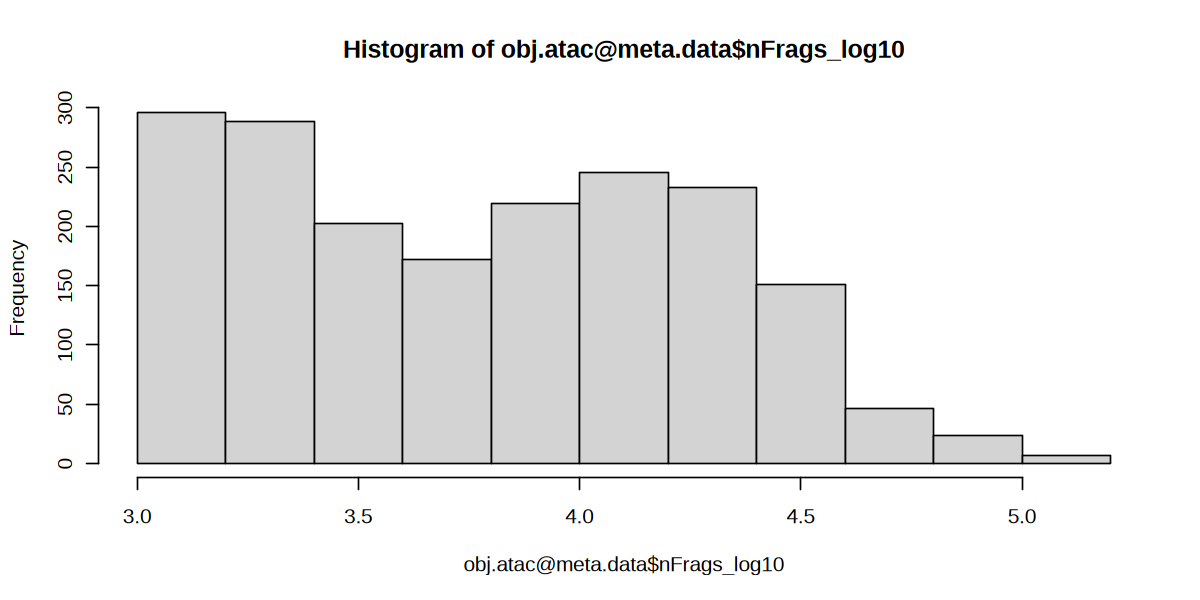

In [100]:
hist(obj.atac@meta.data$nFrags_log10)

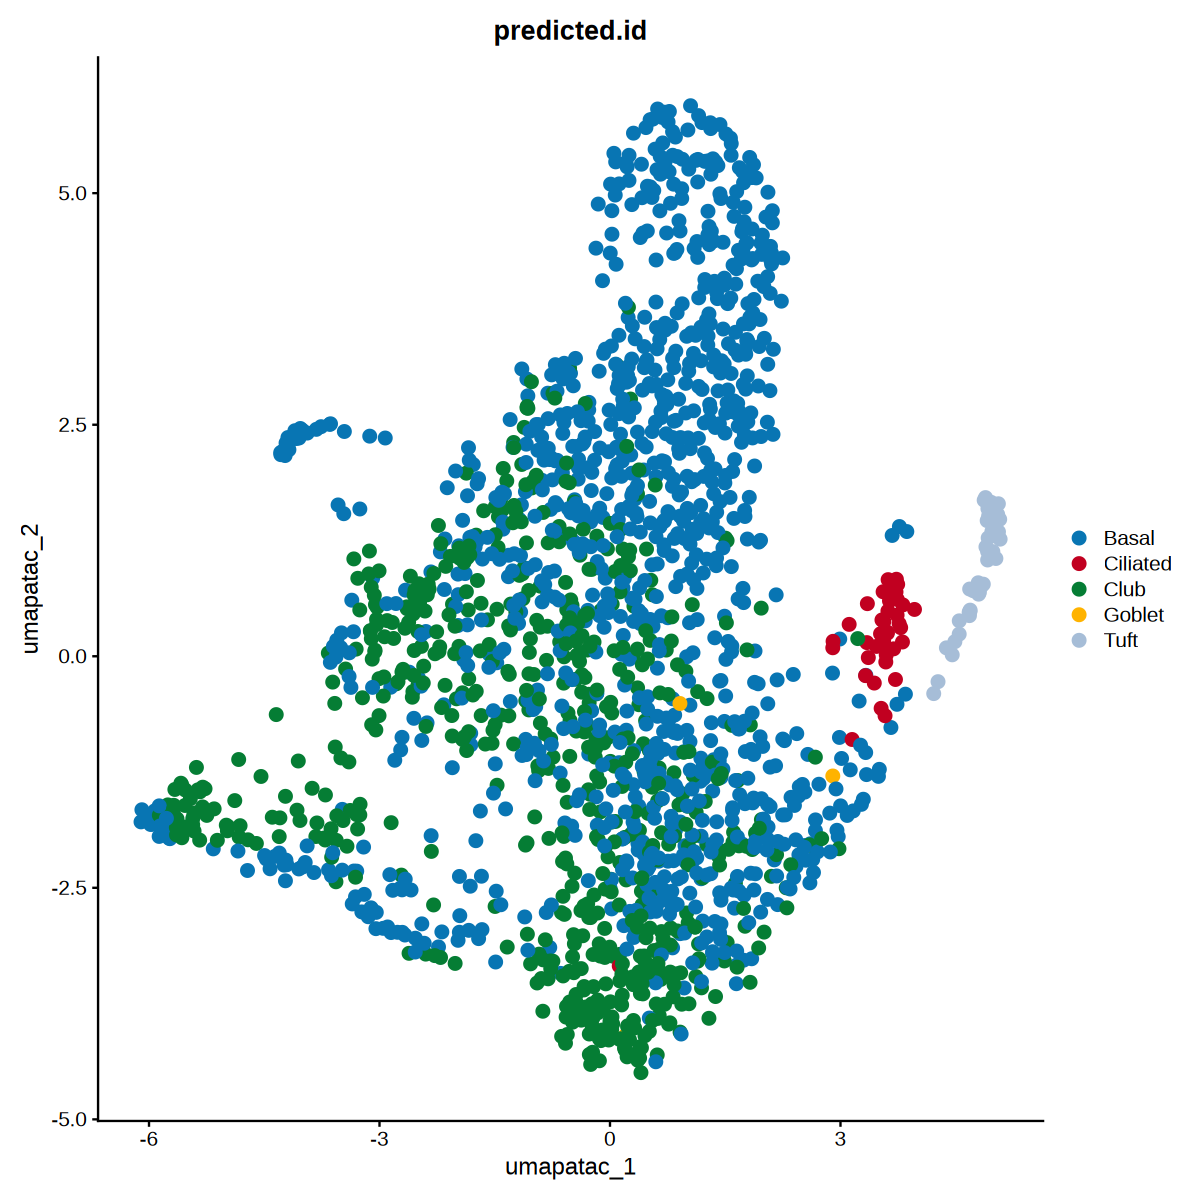

In [101]:
options(repr.plot.height = 10, repr.plot.width = 10)

DimPlot(object = obj.atac, group.by = "predicted.id", label.size = 10, pt.size = 3, cols = cols)

In [102]:
# compute confusion matrix
confusion.matrix <- table(obj.atac$seurat_clusters, obj.atac$predicted.id)

In [103]:
cM_atac_rna <- confusionMatrix(paste0(obj.atac$seurat_clusters), paste0(obj.atac$predicted.id))
cM_atac_rna <- cM_atac_rna / Matrix::rowSums(cM_atac_rna)

agg_record_1632225031 
                    2

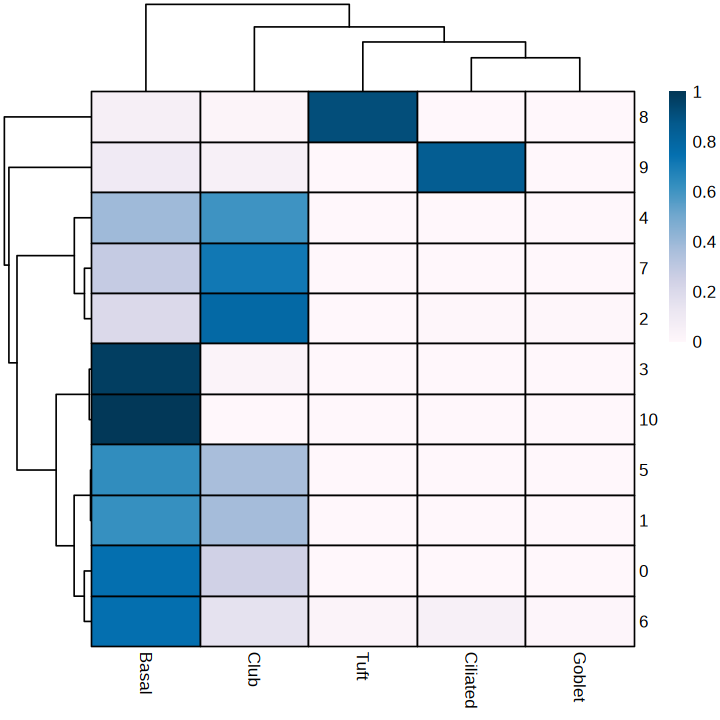

In [104]:
options(repr.plot.height = 6, repr.plot.width = 6)

library(pheatmap)
p_atac_rna <- pheatmap::pheatmap(
  mat = as.matrix(cM_atac_rna), 
  color = paletteContinuous("whiteBlue"), 
  border_color = "black"
)

pdf(glue::glue("{out_dir}/confusion_matrix_atac_rna.pdf"), width = 6, height = 6)
print(p_atac_rna)
dev.off()

In [105]:
obj.atac@meta.data$cell_type <- stringr::str_replace_all(obj.atac@meta.data$seurat_clusters, 
c("10" = "Basal", "1" = "Club", "2" = "Club", "3" = "Basal", "4" = "Club", 
"5" = "Club", "6" = "Club", "7" = "Club", "8" = "Tuft", "9" = "Ciliated", "0" = "Basal"))

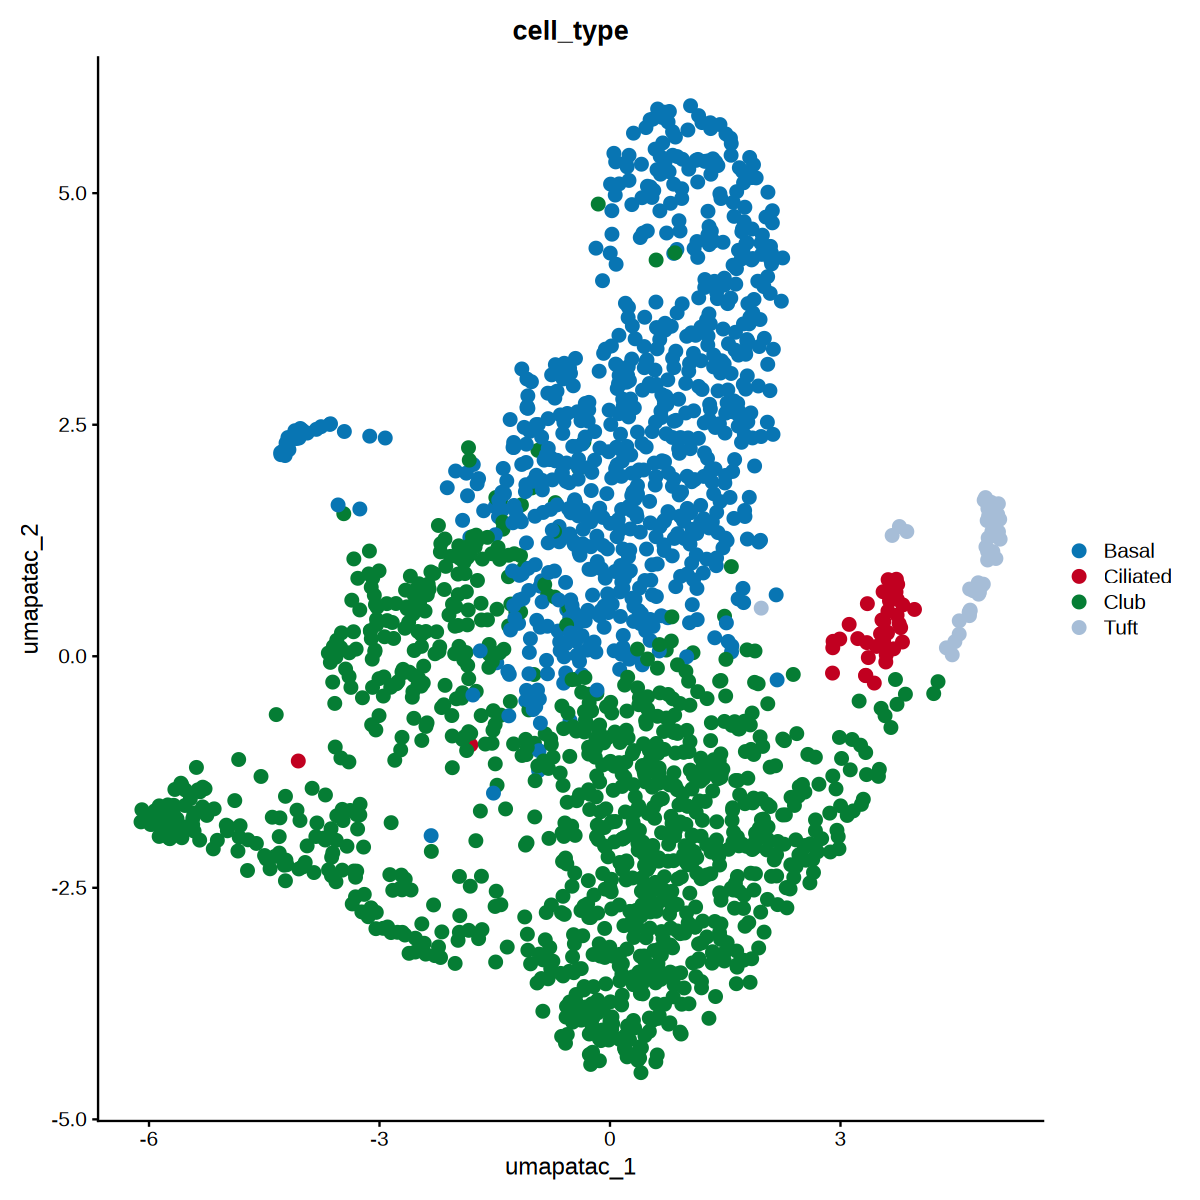

In [106]:
options(repr.plot.height = 10, repr.plot.width = 10)

DimPlot(object = obj.atac, group.by = "cell_type", label.size = 10, pt.size = 3, cols = cols)

In [107]:
saveRDS(obj.rna, file = glue::glue("{out_dir}/snRNA.Rds"))
saveRDS(obj.atac, file = glue::glue("{out_dir}/snATAC.Rds"))
saveRDS(coembed, file = glue::glue("{out_dir}/coembed.Rds"))

In [108]:
write.csv(as.data.frame(obj.atac@meta.data), 
          file = glue::glue("{out_dir}/snATAC_metadata.csv"))

In [109]:
obj.atac

An object of class Seurat 
172727 features across 1883 samples within 3 assays 
Active assay: RNA (16887 features, 0 variable features)
 1 layer present: data
 2 other assays present: ATAC, GeneActivity
 2 dimensional reductions calculated: lsi, umap_atac